In [81]:
# \\192.168.101.51
import pandas as pd
df=pd.read_csv("Fish.csv")

In [2]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


In [3]:
df.head()

,Species,Weight,Length1,Length2,Length3,Height,Width
0,Bream,242.0,23.2,25.4,30.0,11.5200,4.0200
1,Bream,290.0,24.0,26.3,31.2,12.4800,4.3056
2,Bream,340.0,23.9,26.5,31.1,12.3778,4.6961
3,Bream,363.0,26.3,29.0,33.5,12.7300,4.4555
4,Bream,430.0,26.5,29.0,34.0,12.4440,5.1340


In [4]:
df.isnull().sum()

Species    0
Weight     0
Length1    0
Length2    0
Length3    0
Height     0
Width      0
dtype: int64

In [6]:
df.duplicated().sum()

np.int64(0)

Simple Linear regression

<Axes: >

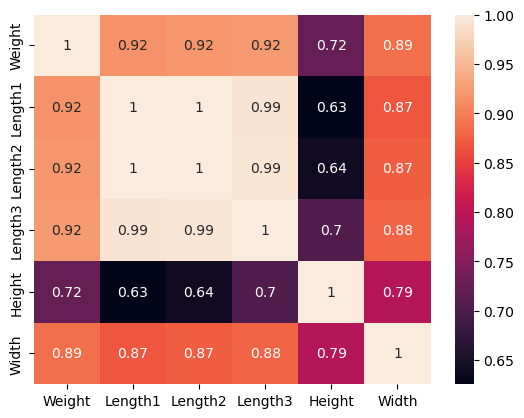

In [9]:
sns.heatmap(df.corr(numeric_only=True),annot=True)

<Axes: xlabel='Length1', ylabel='Width'>

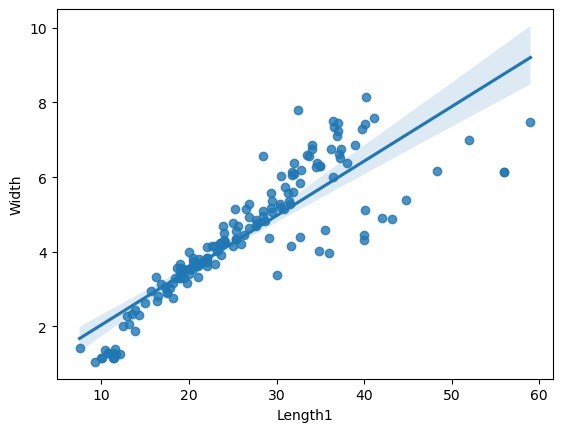

In [11]:
sns.regplot(data=df,x="Length1",y="Width")

In [12]:
df.columns

Index(['Species', 'Weight', 'Length1', 'Length2', 'Length3', 'Height',
       'Width'],
      dtype='object')

for predicting weight from length1

In [13]:
x=df[["Length1"]]
y=df[["Width"]]

In [14]:
x,y

(     Length1
 0       23.2
 1       24.0
 2       23.9
 3       26.3
 4       26.5
 ..       ...
 154     11.5
 155     11.7
 156     12.1
 157     13.2
 158     13.8
 
 [159 rows x 1 columns],
       Width
 0    4.0200
 1    4.3056
 2    4.6961
 3    4.4555
 4    5.1340
 ..      ...
 154  1.3936
 155  1.2690
 156  1.2558
 157  2.0672
 158  1.8792
 
 [159 rows x 1 columns])

split into two train part and test

In [30]:
from sklearn.model_selection import train_test_split

In [31]:
 x_train, x_test, y_train, y_test = train_test_split( x, y, test_size=0.2, random_state=42)

In [32]:
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(127, 1)
(32, 1)
(127, 1)
(32, 1)


Build a model

In [33]:
from sklearn.linear_model import LinearRegression

In [34]:
model=LinearRegression()


In [35]:
model.fit(x_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [36]:
model.coef_

array([[0.14009787]])

In [37]:
model.intercept_

array([0.75518409])

In [41]:
y_pred=model.predict(x_test)

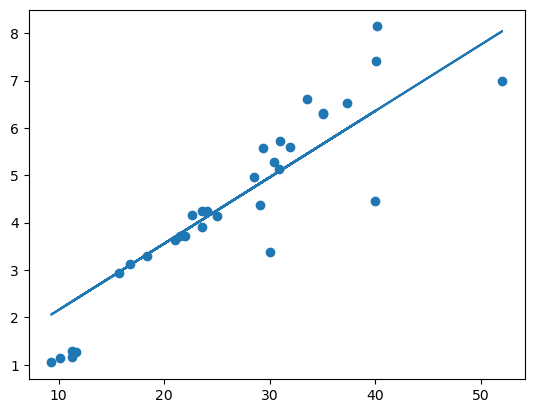

In [42]:
plt.plot(x_test,y_pred)
plt.scatter(x_test,y_test)
plt.show()

In [45]:
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

In [47]:
print(mean_absolute_error(y_test,y_pred))
print(mean_squared_error(y_test,y_pred))
print(r2_score(y_test,y_pred))

0.6096644974505345
0.6623478028188455
0.8112367680244194


In [49]:
model.predict(np.array([[25]]))

C:\ProgramData\Anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([[4.25763096]])

In [50]:
df.columns

Index(['Species', 'Weight', 'Length1', 'Length2', 'Length3', 'Height',
       'Width'],
      dtype='object')

for predicting weight from len1,len2.len3,height

In [58]:
# x1=df[["Length1"]]
# x2=df[["Width"]]
# x3=df[["Length2"]]
# x4=df[["Length3"]]
# x5=df[["Height"]]
# y1=df[["Weight"]]

In [60]:
from sklearn.linear_model import LinearRegression


In [63]:
x=df.drop(['Species','Weight'],axis=1)

In [68]:
y=df[["Weight"]]
x_train, x_test, y_train, y_test = train_test_split( x, y, test_size=0.2, random_state=42)
model=LinearRegression()
model.fit(x_train,y_train)
y_pred=model.predict(x_test)
print(mean_absolute_error(y_test,y_pred))
print(mean_squared_error(y_test,y_pred))
print(r2_score(y_test,y_pred))


103.90941708422304
16763.887193140767
0.8821430593048694


In [ ]:
# plot mse,r2_score for test size=0.75,0.8,0.85,0.9,0.95

In [83]:
y=df[["Weight"]]
test=[0.75,0.8,0.85,0.9,0.95]
mse=[]
r2=[]
for i in test:
    x_train, x_test, y_train, y_test = train_test_split( x, y, test_size=i, random_state=42)
    model=LinearRegression()
    model.fit(x_train,y_train)
    y_pred=model.predict(x_test)
    mse.append(mean_squared_error(y_test,y_pred))
    r2.append(r2_score(y_test,y_pred))
    print(model.predict(np.array([[10,10,10,10,10]])))


[[748.07173286]]
[[937.588622]]
[[1402.2086784]]
[[1485.16232341]]
[[361.41492701]]


C:\ProgramData\Anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
C:\ProgramData\Anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
C:\ProgramData\Anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
C:\ProgramData\Anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
C:\ProgramData\Anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


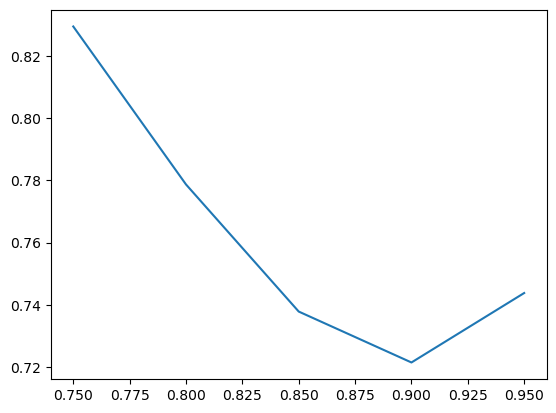

In [73]:
plt.plot(test,r2)

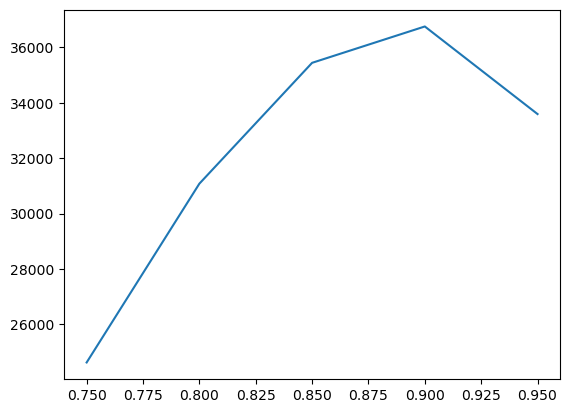

In [74]:
plt.plot(test,mse)

In [85]:
df=pd.read_csv("Ice_cream selling data.csv")

In [86]:
df.head()

,Temperature (°C),Ice Cream Sales (units)
0,-4.662263,41.842986
1,-4.316559,34.661120
2,-4.213985,39.383001
3,-3.949661,37.539845
4,-3.578554,32.284531


In [96]:
x=df[["Temperature (°C)"]]
y=df[["Ice Cream Sales (units)"]]
x_train, x_test, y_train, y_test = train_test_split( x, y, test_size=0.2, random_state=40)
model=LinearRegression()
model.fit(x_train,y_train)
y_pred=model.predict(x_test)
print(mean_absolute_error(y_test,y_pred))
print(mean_squared_error(y_test,y_pred))
print(r2_score(y_test,y_pred))

14.28681469049703
288.6596992061606
-0.4122082415321706


<Axes: xlabel='Temperature (°C)', ylabel='Ice Cream Sales (units)'>

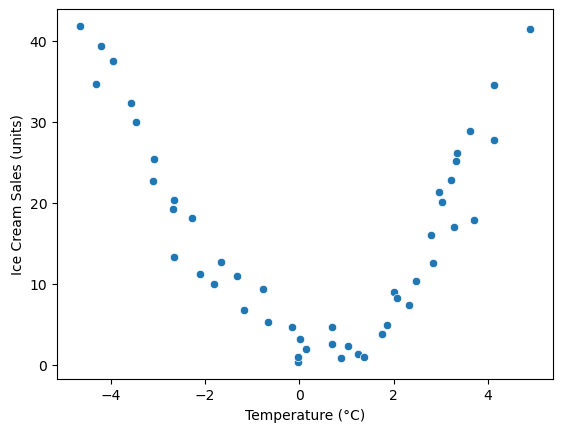

In [93]:
sns.scatterplot(data=df,x="Temperature (°C)",y="Ice Cream Sales (units)")

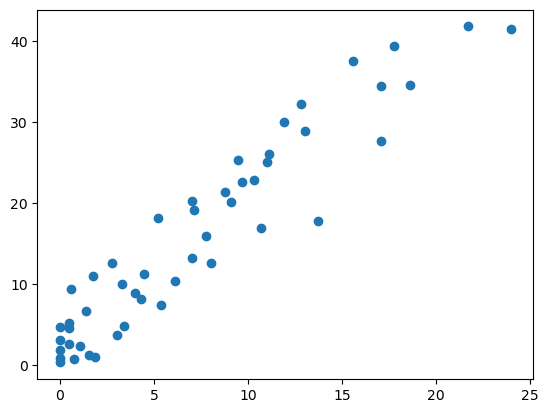

In [94]:
plt.scatter(df['Temperature (°C)']*df['Temperature (°C)'],df['Ice Cream Sales (units)'])